In [255]:
import numpy as np

In [256]:
import pandas as pd

In [257]:
import matplotlib as plt

In [258]:
df = pd.read_csv("train_data1.csv")

In [259]:
df.head()

,timestamp,open,high,low,close
0,03-01-2021 09:30,99.977582,100.019016,99.951704,99.981656
1,03-01-2021 09:45,100.032918,100.091286,99.955384,100.024571
2,03-01-2021 10:00,100.047690,100.123988,99.936800,100.025658
3,03-01-2021 10:15,100.026924,100.114907,99.975890,100.008880
4,03-01-2021 10:30,100.039566,100.094328,99.980561,100.034038


In [260]:
df.columns

Index(['timestamp', 'open', 'high', 'low', 'close'], dtype='object')

In [261]:
df.shape

(28418, 5)

In [262]:
df["timestamp"] = pd.to_datetime(df["timestamp"], dayfirst=True)

In [263]:
df= df.sort_values("timestamp")

In [264]:
df = df.reset_index(drop = True)

In [265]:
df = df.set_index("timestamp")

In [266]:
df.index[:5]

DatetimeIndex(['2021-01-03 09:30:00', '2021-01-03 09:45:00',
               '2021-01-03 10:00:00', '2021-01-03 10:15:00',
               '2021-01-03 10:30:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)

In [267]:
import matplotlib.pyplot as plt

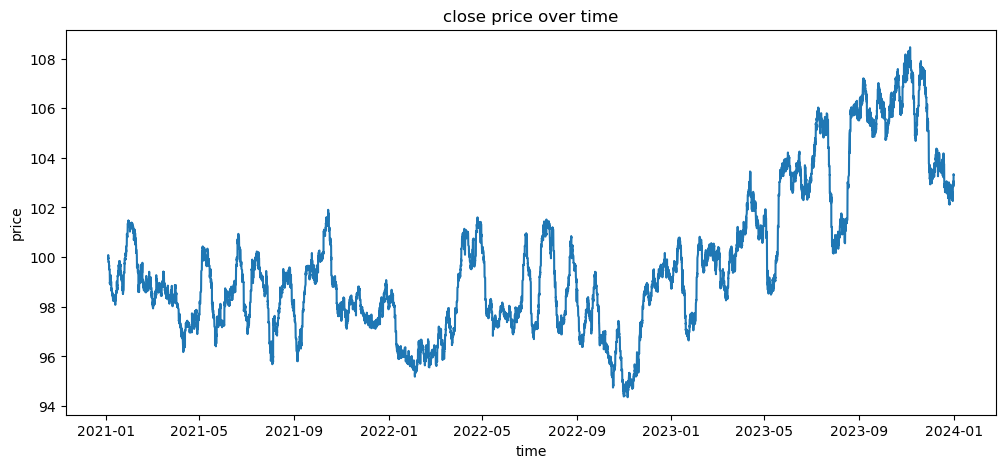

In [268]:
plt.figure(figsize= (12,5))
plt.plot(df.index, df["close"])
plt.title("close price over time")
plt.xlabel("time")
plt.ylabel("price")
plt.show()

In [269]:
df['close']

timestamp
2021-01-03 09:30:00     99.981656
2021-01-03 09:45:00    100.024571
2021-01-03 10:00:00    100.025658
2021-01-03 10:15:00    100.008880
2021-01-03 10:30:00    100.034038
                          ...    
2023-12-31 14:45:00    103.227844
2023-12-31 15:00:00    103.257699
2023-12-31 15:15:00    103.342713
2023-12-31 15:30:00    103.294614
2023-12-31 15:45:00    103.323317
Name: close, Length: 28418, dtype: float64

In [270]:
df['close_prev'] = df['close'].shift(1)

In [271]:
df['down_move'] = df['close'] < df['close_prev']

In [272]:
window = 20

In [273]:
df['rolling_min'] = df['close'].rolling(window).min()

In [274]:
tolerance = 0.002   # 0.2% tolerance

df['is_bingo'] = df['close'] <= df['rolling_min'] * (1 + tolerance)


In [275]:
df['close_next'] = df['close'].shift(-1)

In [276]:
df['confirmation'] = df['close_next'] > df['close']

In [277]:
df['local_low'] = (
    df['is_bingo'] &
    df['confirmation']
)


In [278]:
df[df['local_low']].head()

,open,high,low,close,close_prev,down_move,rolling_min,is_bingo,close_next,confirmation,local_low
timestamp,,,,,,,,,,,
2021-01-03 14:15:00,99.848836,99.887243,99.766952,99.854787,99.908638,True,99.854787,True,99.872369,True,True
2021-01-03 14:30:00,99.880561,99.920300,99.792161,99.872369,99.854787,False,99.854787,True,99.939100,True,True
2021-01-03 15:45:00,99.823022,99.891522,99.735616,99.802212,99.826190,True,99.802212,True,99.819162,True,True
2021-01-04 10:00:00,99.713691,99.756911,99.670953,99.734680,99.785914,True,99.734680,True,99.783979,True,True
2021-01-04 10:30:00,99.742294,99.821134,99.698565,99.726523,99.783979,True,99.726523,True,99.733596,True,True


In [279]:
df[df['local_low']].head(10)

,open,high,low,close,close_prev,down_move,rolling_min,is_bingo,close_next,confirmation,local_low
timestamp,,,,,,,,,,,
2021-01-03 14:15:00,99.848836,99.887243,99.766952,99.854787,99.908638,True,99.854787,True,99.872369,True,True
2021-01-03 14:30:00,99.880561,99.920300,99.792161,99.872369,99.854787,False,99.854787,True,99.939100,True,True
2021-01-03 15:45:00,99.823022,99.891522,99.735616,99.802212,99.826190,True,99.802212,True,99.819162,True,True
2021-01-04 10:00:00,99.713691,99.756911,99.670953,99.734680,99.785914,True,99.734680,True,99.783979,True,True
2021-01-04 10:30:00,99.742294,99.821134,99.698565,99.726523,99.783979,True,99.726523,True,99.733596,True,True
2021-01-04 11:15:00,99.690018,99.726496,99.638287,99.698109,99.700657,True,99.698109,True,99.712006,True,True
2021-01-04 11:45:00,99.653435,99.735328,99.586538,99.665234,99.712006,True,99.665234,True,99.666099,True,True
2021-01-04 12:30:00,99.604137,99.667005,99.534655,99.610378,99.625434,True,99.610378,True,99.650741,True,True
2021-01-04 12:45:00,99.642049,99.709814,99.569832,99.650741,99.610378,False,99.610378,True,99.677567,True,True


In [280]:
df['close_prev'] = df['close'].shift(1)      # Previous close (already exists, fine to reuse)

df['rolling_max'] = df['close'].rolling(window).max()
                                             # Highest close in last 20 candles

df['is_star'] = df['close'] == df['rolling_max']
                                             # Candidate local high (STAR candle)

df['confirmation_high'] = df['close_next'] < df['close']
                                             # Next candle closes lower → confirms reversal

df['local_high'] = (
    df['is_star'] &
    df['confirmation_high']
)
                                             # Final local high definition

df[df['local_high']].head(10)                # Sanity check local highs


,open,high,low,close,close_prev,down_move,rolling_min,is_bingo,close_next,confirmation,local_low,rolling_max,is_star,confirmation_high,local_high
timestamp,,,,,,,,,,,,,,,
2021-01-06 12:00:00,99.210972,99.273876,99.156357,99.225722,99.185721,False,98.883805,False,99.214684,False,False,99.225722,True,True,True
2021-01-06 12:45:00,99.304069,99.354672,99.213426,99.280904,99.215832,False,98.883805,False,99.264853,False,False,99.280904,True,True,True
2021-01-09 11:30:00,98.538034,98.588338,98.457760,98.536391,98.473908,False,98.468840,True,98.519304,False,False,98.536391,True,True,True
2021-01-09 12:00:00,98.528670,98.608899,98.441054,98.539458,98.519304,False,98.468840,True,98.462750,False,False,98.539458,True,True,True
2021-01-12 10:30:00,98.396671,98.457860,98.355252,98.393233,98.301381,False,98.254661,True,98.389868,False,False,98.393233,True,True,True
2021-01-12 11:00:00,98.438882,98.508975,98.385040,98.448106,98.389868,False,98.254661,True,98.415789,False,False,98.448106,True,True,True
2021-01-13 10:15:00,98.446444,98.508736,98.402512,98.454737,98.384496,False,98.078817,False,98.418390,False,False,98.454737,True,True,True
2021-01-13 12:00:00,98.539560,98.619089,98.473133,98.553034,98.499332,False,98.078817,False,98.482458,False,False,98.553034,True,True,True
2021-01-13 14:45:00,98.611977,98.687501,98.508750,98.589768,98.570972,False,98.384496,False,98.588918,False,False,98.589768,True,True,True


In [281]:
df['local_high'].sum()


np.int64(1944)

In [282]:
df['ll_price'] = np.where(df['local_low'], df['close'], np.nan)
df['lh_price'] = np.where(df['local_high'], df['close'], np.nan)

In [283]:
df['ll_price'] = df['ll_price'].ffill()
df['lh_price'] = df['lh_price'].ffill()

In [284]:
df['prev_ll'] = df['ll_price'].shift(1)
df['prev_lh'] = df['lh_price'].shift(1)

In [285]:
df['bullish'] = (
    (df['ll_price'] > df['prev_ll']) &
    (df['lh_price'] > df['prev_lh'])
)

# Long-term structure using higher-level trend
long_window = 96 * 20   # ~20 trading days (defensible)

df['long_ma'] = df['close'].rolling(long_window).mean()

# Structural bullish regime:
# price is above long-term average
df['bullish_structural'] = df['close'] > df['long_ma']

In [286]:
df['entry'] = df['local_low'] & df['bullish_structural']

In [287]:
df['exit_wrong'] = (
    df['local_low'] &
    (df['ll_price'] < df['prev_ll'])
)

In [288]:
df['exit_right'] = (
    df['local_high'] &
    (df['lh_price'] < df['prev_lh'])
)

In [289]:
df['exit'] = df['exit_wrong'] | df['exit_right']

In [290]:
trades = []
in_trade = False

for ts, row in df.iterrows():
    if not in_trade and row['entry']:
        entry_price = row['close']
        entry_time = ts
        in_trade = True

    elif in_trade and row['exit']:
        exit_price = row['close']
        exit_time = ts

        trades.append({
            'entry_time': entry_time,
            'exit_time': exit_time,
            'entry_price': entry_price,
            'exit_price': exit_price,
            'return': (exit_price - entry_price) / entry_price
        })

        in_trade = False

trades_df = pd.DataFrame(trades)

In [291]:
len(trades_df)
trades_df.head()

,entry_time,exit_time,entry_price,exit_price,return
0,2021-05-02 11:00:00,2021-05-05 15:15:00,98.142649,100.379469,0.022792
1,2021-05-05 15:45:00,2021-05-06 10:00:00,99.863994,99.902549,0.000386
2,2021-05-06 10:15:00,2021-05-06 10:45:00,99.939194,99.931935,-0.000073
3,2021-05-06 11:15:00,2021-05-06 12:00:00,99.973022,99.930475,-0.000426
4,2021-05-06 12:45:00,2021-05-06 14:00:00,99.867647,99.935011,0.000675


In [292]:
# Safety check before calculating returns
if trades_df.empty:
    print("No completed trades found.")
else:
    total_return = (1 + trades_df['return']).prod() - 1
    print("Total Return:", total_return)


Total Return: 0.14689883748205612


In [293]:
df['is_bingo'].sum()

np.int64(18607)

In [294]:
df['local_low'].sum()


np.int64(8954)

In [295]:
df['entry'].sum()

np.int64(4101)

In [296]:
trades_df['year'] = pd.to_datetime(
    trades_df['entry_time'],
    dayfirst=True
).dt.year

trades_df['year'].value_counts().sort_index()



year
2021    296
2022    343
2023    592
Name: count, dtype: int64

In [297]:
total_return = (1 + trades_df['return']).prod() - 1
sharpe = trades_df['return'].mean() / trades_df['return'].std()

cum_returns = (1 + trades_df['return']).cumprod()
max_dd = (cum_returns / cum_returns.cummax() - 1).min()

total_return, sharpe, max_dd

(np.float64(0.14689883748205612),
 np.float64(0.05300703261639171),
 -0.03942146515124234)

In [298]:
len(trades_df)
trades_df.head()

,entry_time,exit_time,entry_price,exit_price,return,year
0,2021-05-02 11:00:00,2021-05-05 15:15:00,98.142649,100.379469,0.022792,2021
1,2021-05-05 15:45:00,2021-05-06 10:00:00,99.863994,99.902549,0.000386,2021
2,2021-05-06 10:15:00,2021-05-06 10:45:00,99.939194,99.931935,-0.000073,2021
3,2021-05-06 11:15:00,2021-05-06 12:00:00,99.973022,99.930475,-0.000426,2021
4,2021-05-06 12:45:00,2021-05-06 14:00:00,99.867647,99.935011,0.000675,2021


In [299]:
trades_df.to_csv("trade_log.csv", index=False)